# Training a BNN on a Simulation to learn the Systems dynamic


In [60]:

#Importing necessary libraries
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

#Import the classes from the file "control_system_sim.py"
from control_system_sim import SMD_System_Sim
from control_system_sim import PID_Controller

# Try to import torchbnn, install if missing (may fail if no internet)
try:
    import torchbnn as bnn
except ImportError:
    raise ImportError("torchbnn is required but not installed in this environment.")

## Initialize the system and the controller

The system consists of a mass attached to a spring and a dampener. The PID controller applies a force directly to the mass

Second-order spring–mass–damper model

$m x¨ + c ẋ + k x = F$

solved in fixed time steps under the assumption of **constant
acceleration** during each step (small Δt ⇒ good accuracy).


In [61]:
delta_t = 0.01  #timestep for the simulation
system = SMD_System_Sim(mass=1.0, k=1.0,c= 0.1)  #Initialize the system for given constants
pid   = PID_Controller(kp=10.0, ki=2.0, kd=2, max_signal=100.0) #Initialize the pid controller for given constants (Would later be interesting to vary)


## Generate an artificial dataset from the simulation

X = \{(x_t,v_t,a_t,u_t)\} is the position and control input (force, applied by the controller) at time t 

we approx v_t = (x_t-x_t-1)/delta_t and a_t = (x_t - x_t-2)/delta_t^2

Y = \{x_{t+1}\} is the position at time t+1

The Dataset is generated as follows:
 - running the simulation of System and controller for 50s and different command inputs
 - Writing the timeseries to X_list and Y_list
 - Train / testz split of 80 / 20
 - randomly permute the train dataset

In [ ]:

X_list, Y_list = [], []
rng = np.random.default_rng(42)
for step in np.linspace(0, 100, 100):         # 50 different step sizes, where we do a step up at time 10 and then step down at time 30
    t, u, x, r = pid.run_simulation(system, duration=50.0, commands= [[10,step],[30,-step]],time_step = delta_t)
    # create (x_t,(x_t-x_t-1)/delta_t,(x_t-x_t-2)/t^2, u_t) -> x_{t+1}
    X_list.append(np.stack([x[2:-1], (x[2:-1]-x[1:-2])/delta_t,(x[2:-1]-x[0:-3])/delta_t**2 , u[2:-1]], axis=1))
    Y_list.append(x[3:])
#print(X_list)
X = np.concatenate(X_list, axis=0)
Y = np.concatenate(Y_list, axis=0)

# train/test split of 80/20 and permute
perm = rng.permutation(len(X))
train_size = int(0.8 * len(X))
train_idx, test_idx = perm[:train_size], perm[train_size:]

X_train, Y_train = torch.tensor(X[train_idx], dtype=torch.float32), torch.tensor(Y[train_idx], dtype=torch.float32).unsqueeze(1)
X_test,  Y_test  = torch.tensor(X[test_idx], dtype=torch.float32),  torch.tensor(Y[test_idx], dtype=torch.float32).unsqueeze(1)

## Create the Bayesian Neuronal Network (BNN)

Architecture:

- Fully-connected with one hidden layer and tanh as activation function
- Input: 4 dimensional (x_t, v_t, a_t, u_t)
- Hidden: 32 d
- Out: 1 dimensional (x_t+1)
- Optimizer: Adam
- loss: MSE + kl_loss
- prior of weights: Gaussian with mean 0 and sigma 0.1


In [63]:

class BNN(nn.Module):
    def __init__(self, in_dim=4, hidden=32):
        super().__init__()
        self.net = nn.Sequential(
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1,in_features=in_dim,out_features = hidden),
            nn.Tanh(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1,in_features=hidden,out_features = hidden),
            nn.Tanh(),
            bnn.BayesLinear(prior_mu=0, prior_sigma=0.1,in_features=hidden,out_features = 1)
        )

    def forward(self, x):
        return self.net(x)


bnn_model = BNN()
optimizer = torch.optim.Adam(bnn_model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

## Training

In [64]:
epochs = 50000
bnn_model.train()
for epoch in range(epochs):
    optimizer.zero_grad()
    preds = bnn_model(X_train)
    loss = loss_fn(preds, Y_train)
    # add KL term for Bayesian layers
    kl = sum(m.kl_loss() for m in bnn_model.modules() if hasattr(m, "kl_loss"))
    total_loss = loss + 1e-6 * kl
    total_loss.backward()
    optimizer.step()
    if (epoch+1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}/{epochs} - MSE: {loss.item():.4e}")

Epoch  50/50000 - MSE: 2.8971e+03
Epoch 100/50000 - MSE: 2.8496e+03
Epoch 150/50000 - MSE: 2.7395e+03
Epoch 200/50000 - MSE: 2.6685e+03
Epoch 250/50000 - MSE: 2.5686e+03
Epoch 300/50000 - MSE: 2.4913e+03
Epoch 350/50000 - MSE: 2.2859e+03
Epoch 400/50000 - MSE: 2.1853e+03
Epoch 450/50000 - MSE: 2.1834e+03
Epoch 500/50000 - MSE: 2.1407e+03
Epoch 550/50000 - MSE: 1.8686e+03
Epoch 600/50000 - MSE: 1.7517e+03
Epoch 650/50000 - MSE: 1.9717e+03
Epoch 700/50000 - MSE: 1.8164e+03
Epoch 750/50000 - MSE: 1.8313e+03
Epoch 800/50000 - MSE: 1.8148e+03
Epoch 850/50000 - MSE: 1.5366e+03
Epoch 900/50000 - MSE: 1.8732e+03
Epoch 950/50000 - MSE: 1.6555e+03
Epoch 1000/50000 - MSE: 1.4591e+03
Epoch 1050/50000 - MSE: 1.2810e+03
Epoch 1100/50000 - MSE: 1.8527e+03
Epoch 1150/50000 - MSE: 1.7723e+03
Epoch 1200/50000 - MSE: 1.7920e+03
Epoch 1250/50000 - MSE: 1.5467e+03
Epoch 1300/50000 - MSE: 1.1444e+03
Epoch 1350/50000 - MSE: 1.2897e+03
Epoch 1400/50000 - MSE: 1.0888e+03
Epoch 1450/50000 - MSE: 1.5901e+03
Epoc

## Evaluation of Uncertainty

The important point about a BNN is that it learns a distribution on the weights and hence we can quantify the uncertainty about its predictions.

This means that for a given input, the output of the BNN is still probabilistic. To quantify the uncertainty we repeatedly sample for our input sequence (mc_samples times) and calculate the mean and the standard deviation.

In [74]:
bnn_model.eval()
with torch.no_grad():
    # simulate unseen input sequence of controls
    t_eval, u_eval, x_eval, r = pid.run_simulation(system, duration=120.0, commands= [[0,70], [20,30], [40,50],[60,10],[80,90]])
    inputs = torch.tensor(np.stack([x_eval[2:-1], (x_eval[2:-1]-x_eval[1:-2])/delta_t, (x_eval[2:-1]-x_eval[0:-3])/delta_t**2 , u_eval[2:-1]], axis=1), dtype=torch.float32)

    # Monte Carlo sampling
    mc_samples = 1000
    preds_samples = torch.stack([bnn_model(inputs).squeeze(1) for _ in range(mc_samples)], dim=0)
    mean_pred = preds_samples.mean(0).numpy()
    std_pred  = preds_samples.std(0).numpy()

## Plot the result

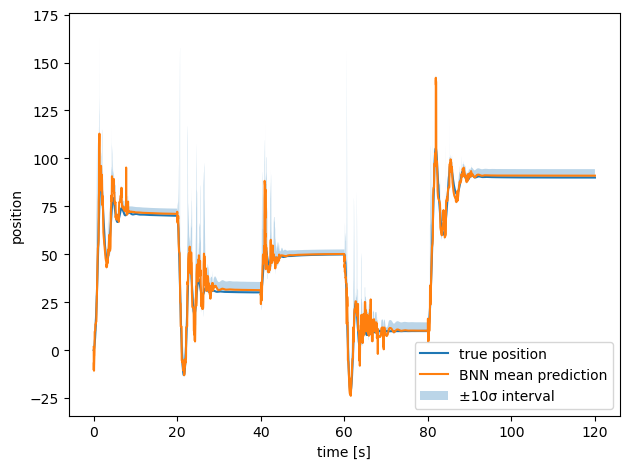

In [75]:
plt.figure()
time = t_eval[3:]  # x_{t+1} timestamps
plt.plot(time, x_eval[3:], label="true position")
plt.plot(time, mean_pred, label="BNN mean prediction")
plt.fill_between(time, mean_pred-10*std_pred, mean_pred+10*std_pred, alpha=0.3, label="±10σ interval")
plt.xlabel("time [s]")
plt.ylabel("position")
plt.legend()
plt.tight_layout()

plt.show()